In [1]:
#Import necessary libraries - NC
#Here we import libraries for data handling, model building, and visualization -NC

import os
import numpy as np
import matplotlib.pyplot as plt #Visualization library -NC
import tensorflow as tf #TensorFlow for building and training the model -NC
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import pathlib #For handling file paths -NC

In [2]:
#Define dataset path and parameters - NC
dataset_path = pathlib.Path("Leaf_Disease")
img_height, img_width = 224, 224
batch_size = 32

In [3]:
#Data augmentation and preparation - NC
#Create an ImageDataGenerator with data augmentation for training and validation sets - NC

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    subset='training',
    class_mode='sparse'
)
class_names = list(train_data.class_indices.keys())

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    subset='validation',
    class_mode='sparse'
)


Found 17778 images belonging to 22 classes.
Found 4435 images belonging to 22 classes.


In [4]:
#Build the CNN model - NC

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_data.num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


C:\Users\nicc\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 22)                  │           2,838 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,171,798 (42.62 MB)

 Trainable params: 11,171,798 (42.62 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
#Implement early stopping to prevent overfitting - NC

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_data.classes),
    y=train_data.classes,
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

print("Class weights:", class_weight_dict)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    #callbacks=[early_stop], - I comented this out to see if early stopping was negativley affecting the model's confidence, 
    # as I commented it out and increased the epochs to 20 I was able to see a significant increase in confidence for the model post training.
    # Conclusion, I have found it to be more effective to 
    class_weight=class_weight_dict,
)

Class weights: {0: np.float64(4.040454545454545), 1: np.float64(6.3132102272727275), 2: np.float64(6.516862170087976), 3: np.float64(8.08090909090909), 4: np.float64(2.7117144600366077), 5: np.float64(3.3530743115805355), 6: np.float64(4.725677830940989), 7: np.float64(1.0126452494873548), 8: np.float64(0.6830861446246062), 9: np.float64(1.0101136363636363), 10: np.float64(1.0101136363636363), 11: np.float64(6.623695976154993), 12: np.float64(0.47478901826727915), 13: np.float64(1.0101136363636363), 14: np.float64(0.5288553069966683), 15: np.float64(1.060486757337151), 16: np.float64(0.5702829280810933), 17: np.float64(0.6026032133414684), 18: np.float64(0.7189420899385313), 19: np.float64(0.3147997308495945), 20: np.float64(2.7026451809060505), 21: np.float64(0.6347925444547597)}


C:\Users\nicc\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
556/556 ━━━━━━━━━━━━━━━━━━━━ 850s 2s/step - accuracy: 0.1252 - loss: 2.8394 - val_accuracy: 0.4016 - val_loss: 1.9198
Epoch 2/20
556/556 ━━━━━━━━━━━━━━━━━━━━ 825s 1s/step - accuracy: 0.3839 - loss: 1.9258 - val_accuracy: 0.5939 - val_loss: 1.2727
Epoch 3/20
556/556 ━━━━━━━━━━━━━━━━━━━━ 803s 1s/step - accuracy: 0.4855 - loss: 1.5493 - val_accuracy: 0.6228 - val_loss: 1.1545
Epoch 4/20
556/556 ━━━━━━━━━━━━━━━━━━━━ 939s 2s/step - accuracy: 0.5506 - loss: 1.3411 - val_accuracy: 0.6767 - val_loss: 0.9723
Epoch 5/20
556/556 ━━━━━━━━━━━━━━━━━━━━ 804s 1s/step - accuracy: 0.5910 - loss: 1.2356 - val_accuracy: 0.7218 - val_loss: 0.8369
Epoch 6/20
556/556 ━━━━━━━━━━━━━━━━━━━━ 780s 1s/step - accuracy: 0.6119 - loss: 1.1192 - val_accuracy: 0.7362 - val_loss: 0.7832
Epoch 7/20
556/556 ━━━━━━━━━━━━━━━━━━━━ 803s 1s/step - accuracy: 0.6293 - loss: 1.0902 - val_accuracy: 0.7705 - val_loss: 0.6764
Epoch 8/20
556/556 ━━━━━━━━━━━━━━━━━━━━ 941s 2s/step - accuracy: 0.6687 - loss: 0.9766 - val_accu

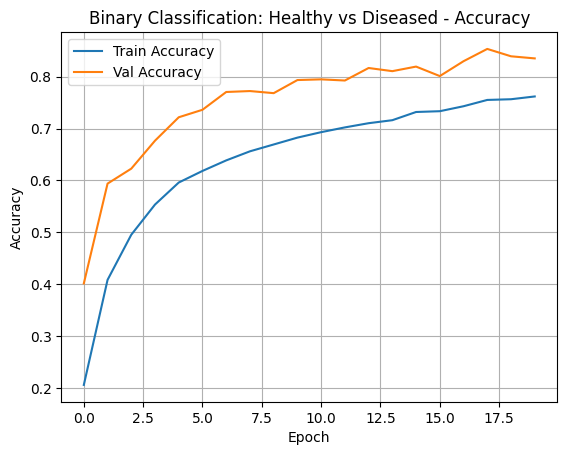

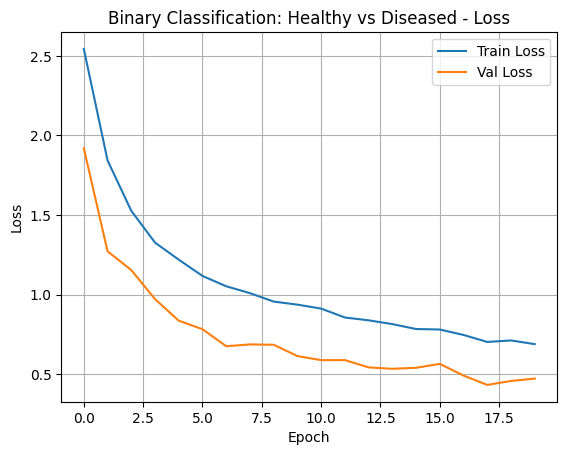

In [6]:
#important visualization of training and validation accuracy over epochs - NC

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Binary Classification: Healthy vs Diseased - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

#Important visualization of training loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Binary Classification: Healthy vs Diseased - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# I wanted to make a note here, notice how this model is trained. 
# The train accuracy keeps increasing while validation accuracy is lower and bounces around. 
# That means the model is learning patterns on the training data, but it does not generalize perfectly; some overfitting and class difficulty/imbalance show up on validation. 
# Overall we have a val accuracy ~0.75 with some classes much stronger than others.
# Another key note is that our model's training accuracy increases with each epoch.

In [7]:
# Function to predict a single image - NC

from tensorflow.keras.preprocessing import image

def predict_image(img_path: str):
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(img_height, img_width))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_array)
    predicted_class_index = int(np.argmax(predictions[0]))
    predicted_class_name = class_names[predicted_class_index]
    confidence = float(np.max(predictions[0]) * 100.0)

    # Print in desired format
    print(f"predicted class: {predicted_class_name} with confidence: {confidence:.2f}%")
    

In [ ]:
predict_image(r"C:\Users\dir_to_image")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
predicted class: Grape Brown spot leaf with confidence: 98.81%


Found 4435 images belonging to 22 classes.
139/139 ━━━━━━━━━━━━━━━━━━━━ 111s 796ms/step


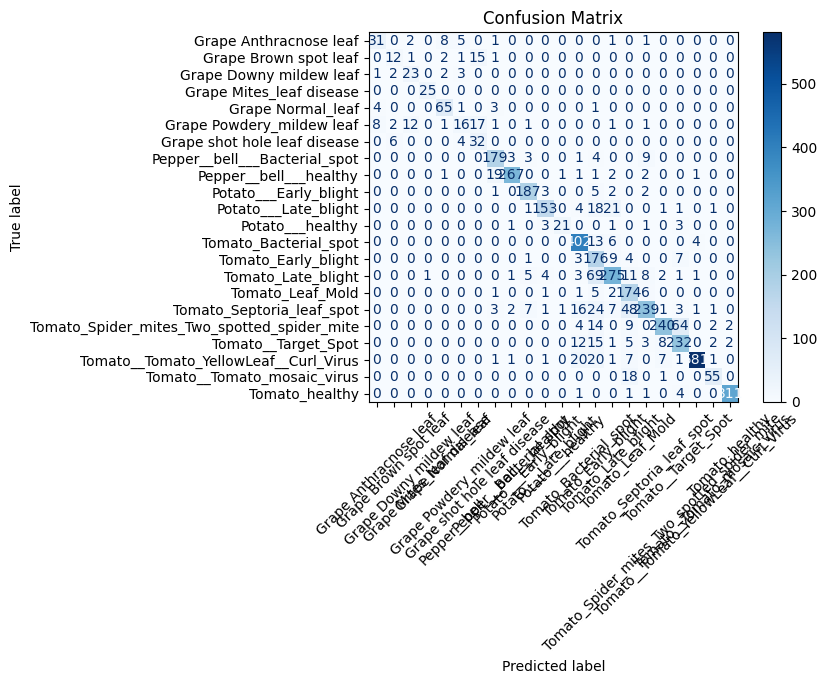

                                             precision    recall  f1-score   support

                     Grape Anthracnose leaf       0.70      0.63      0.67        49
                      Grape Brown spot leaf       0.55      0.38      0.44        32
                    Grape Downy mildew leaf       0.61      0.74      0.67        31
                   Grape Mites_leaf disease       0.96      1.00      0.98        25
                          Grape Normal_leaf       0.82      0.88      0.85        74
                  Grape Powdery_mildew leaf       0.53      0.27      0.36        60
               Grape shot hole leaf disease       0.50      0.76      0.60        42
              Pepper__bell___Bacterial_spot       0.85      0.90      0.88       199
                     Pepper__bell___healthy       0.97      0.91      0.94       295
                      Potato___Early_blight       0.91      0.94      0.92       200
                       Potato___Late_blight       0.92      0.77

In [9]:
#Proving Accuracy with a confusion matrix

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    subset='validation',
    shuffle=False
)

y_true = val_data.classes
y_pred = np.argmax(model.predict(val_data), axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(train_data.class_indices.keys())
)

disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=list(train_data.class_indices.keys())))

In [10]:
import collections 
print("Training Counts: ", collections.Counter(train_data.classes))
print("Validation Counts: ", collections.Counter(val_data.classes))
print("Class indicies: ", train_data.class_indices)

Training Counts:  Counter({np.int32(19): 2567, np.int32(12): 1702, np.int32(14): 1528, np.int32(16): 1417, np.int32(17): 1341, np.int32(21): 1273, np.int32(8): 1183, np.int32(18): 1124, np.int32(9): 800, np.int32(10): 800, np.int32(13): 800, np.int32(7): 798, np.int32(15): 762, np.int32(20): 299, np.int32(4): 298, np.int32(5): 241, np.int32(0): 200, np.int32(6): 171, np.int32(1): 128, np.int32(2): 124, np.int32(11): 122, np.int32(3): 100})
Validation Counts:  Counter({np.int32(19): 641, np.int32(12): 425, np.int32(14): 381, np.int32(16): 354, np.int32(17): 335, np.int32(21): 318, np.int32(8): 295, np.int32(18): 280, np.int32(9): 200, np.int32(10): 200, np.int32(13): 200, np.int32(7): 199, np.int32(15): 190, np.int32(4): 74, np.int32(20): 74, np.int32(5): 60, np.int32(0): 49, np.int32(6): 42, np.int32(1): 32, np.int32(2): 31, np.int32(11): 30, np.int32(3): 25})
Class indicies:  {'Grape Anthracnose leaf': 0, 'Grape Brown spot leaf': 1, 'Grape Downy mildew leaf': 2, 'Grape Mites_leaf dise

In [ ]:
#Now we process the images and export our means from running the climate notebook - NC

In [11]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_disease(img_path: str):
    img = image.load_img(img_path, target_size=(img_height, img_width))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)
    predicted_class_index = int(np.argmax(predictions[0]))
    predicted_class_name = class_names[predicted_class_index]
    confidence = float(np.max(predictions[0]) * 100.0)

    return predicted_class_name, confidence    


In [ ]:
#CONTEXT: IF YOU HAVE NOT ALREADY, PLEASE RUN THE climate.ipynb NOTEBOOK TO GET CSV OUTPUT BEFORE RUNNING THE REST OF THIS CODE

import pandas as pd

climate_daily = pd.read_csv(
    r"C:\Users\dir_to_climate_timeseries_with_7d_avg.csv",
    parse_dates=["time"],
)

#climate_daily = (climate_daily.set_index("time").resample("D").mean().reset_index()) # we cannot use this because the different functions are
#running into string errors

climate_daily["time"] = pd.to_datetime(climate_daily["time"])

def get_climate_context(date=None):
    """
    date: optional pd.Timestamp or datetime; if None, use most recent.
    Returns a dict with climate stats to print.
    """
    if climate_daily.empty:
        return None

    if date is None:
        row = climate_daily.iloc[-1]
    else:
        idx = (climate_daily["time"] - pd.Timestamp(date)).abs().idxmin()
        row = climate_daily.iloc[idx]

    return {
        "time": row["time"], 
        "latitude": float(row["latitude"]),
        "longitude": float(row["longitude"]),
        "t2m_daily_mean": float(row["t2m"]),
        "t2m_7d_avg": float(row["t2m_7d_avg"]),
    }


In [45]:
#Change parameters as you please - NC

from datetime import datetime

def diagnose_with_climate(img_path: str, capture_date: datetime | None = None):
    # 1) disease prediction
    disease, confidence = predict_disease(img_path)
    print(f"Predicted disease: {disease} (confidence: {confidence:.2f}%)")

    # 2) climate context
    context = get_climate_context(capture_date)
    if context is None:
        return

    print("\nHistoric climate context (from climate model):")
    print(f"  Closest climate time: {context['time']}")
    print(f"  Latitude: {context['latitude']:.2f} degrees")
    print(f"  Longitude: {context['longitude']:.2f} degrees")  
    print(f"  2m temperature daily mean: {context['t2m_daily_mean']:.2f} K")
    print(f"  2m temperature 7‑day average: {context['t2m_7d_avg']:.2f} K")


In [ ]:
# analyze image and give climate parameters

diagnose_with_climate(
    r"C:\Users\dir_to_image",
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Predicted disease: Grape Brown spot leaf (confidence: 98.81%)

Historic climate context (from climate model):
  Closest climate time: 2024-10-31 18:00:00
  Latitude: 36.15 degrees
  Longitude: -122.53 degrees
  2m temperature daily mean: 287.27 K
  2m temperature 7‑day average: 286.91 K
